## Préparation du df

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
from scipy.stats import linregress

pd.set_option('display.max_columns', None)
df_northern = pd.read_csv(filepath_or_buffer = './data/NH.Ts+dSST.csv', sep = ',', header = 0, low_memory=False)
df_southern = pd.read_csv(filepath_or_buffer = './data/SH.Ts+dSST.csv', sep = ',', header = 0, low_memory=False)
df_global = pd.read_csv(filepath_or_buffer = './data/GLB.Ts+dSST.csv', sep = ',', header = 0, low_memory=False)
df_zone = pd.read_csv(filepath_or_buffer = './data/ZonAnn.Ts+dSST.csv', sep = ',', header = 0, low_memory=False)


In [2]:
df_northern.describe()
df_southern.describe()
df_global.describe()

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,MAM,JJA,SON
count,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000
mean,1952.500000,0.076233,0.085068,0.102671,0.076027,0.063767,0.051849,0.075822,0.075685,0.081301,0.106027,0.098836,0.080822,0.068082,0.095548
std,42.290661,0.446382,0.450972,0.457660,0.419034,0.395672,0.395746,0.378275,0.395652,0.398536,0.402568,0.411772,0.419312,0.386299,0.399208
min,1880.000000,-0.810000,-0.640000,-0.640000,-0.600000,-0.560000,-0.520000,-0.510000,-0.550000,-0.580000,-0.580000,-0.580000,-0.580000,-0.500000,-0.520000
25%,1916.250000,-0.250000,-0.240000,-0.227500,-0.250000,-0.240000,-0.250000,-0.190000,-0.217500,-0.197500,-0.197500,-0.177500,-0.250000,-0.217500,-0.187500
50%,1952.500000,-0.010000,-0.035000,0.015000,-0.015000,-0.035000,-0.050000,-0.030000,-0.040000,-0.055000,0.010000,0.020000,-0.015000,-0.040000,-0.010000
75%,1988.750000,0.320000,0.397500,0.342500,0.297500,0.280000,0.265000,0.290000,0.297500,0.272500,0.260000,0.287500,0.310000,0.310000,0.280000
max,2025.000000,1.370000,1.440000,1.390000,1.310000,1.140000,1.200000,1.200000,1.290000,1.480000,1.340000,1.420000,1.280000,1.230000,1.410000


In [92]:
# Affichage nb lignes et colonnes
df_northern.shape
df_southern.shape
df_global.shape

(146, 19)

In [93]:
# Affichage des types de chaque colonne
df_northern.dtypes
df_southern.dtypes
df_global.dtypes
df_zone.dtypes

Year         int64
Glob       float64
NHem       float64
SHem       float64
24N-90N    float64
24S-24N    float64
90S-24S    float64
64N-90N    float64
44N-64N    float64
24N-44N    float64
EQU-24N    float64
24S-EQU    float64
44S-24S    float64
64S-44S    float64
90S-64S    float64
dtype: object

### Nettoyage des données

In [94]:
# Calcul du nombre de doublons
df_northern.duplicated().sum()
df_southern.duplicated().sum()
df_global.duplicated().sum()
df_zone.duplicated().sum()

np.int64(0)

In [95]:
# Remplacement des données type string par des valeurs nulles et modification du type des colonnes par float

df_northern['Dec'] = df_northern['Dec'].replace(to_replace = "***", value = None)
df_northern['Dec'] = df_northern['Dec'].astype(float)
df_northern['J-D'] = df_northern['J-D'].replace(to_replace = "***", value = None)
df_northern['J-D'] = df_northern['J-D'].astype(float)
df_northern['D-N'] = df_northern['D-N'].replace(to_replace = "***", value = None)
df_northern['D-N'] = df_northern['D-N'].astype(float)
df_northern['DJF'] = df_northern['DJF'].replace(to_replace = "***", value = None)
df_northern['DJF'] = df_northern['DJF'].astype(float)

In [96]:
# Remplacement des données type string par des valeurs nulles et modification du type des colonnes par float

df_southern['Dec'] = df_southern['Dec'].replace(to_replace = "***", value = None)
df_southern['Dec'] = df_southern['Dec'].astype(float)
df_southern['J-D'] = df_southern['J-D'].replace(to_replace = "***", value = None)
df_southern['J-D'] = df_southern['J-D'].astype(float)
df_southern['D-N'] = df_southern['D-N'].replace(to_replace = "***", value = None)
df_southern['D-N'] = df_southern['D-N'].astype(float)
df_southern['DJF'] = df_southern['DJF'].replace(to_replace = "***", value = None)
df_southern['DJF'] = df_southern['DJF'].astype(float)

In [97]:
# Remplacement des données type string par des valeurs nulles et modification du type des colonnes par float

df_global['Dec'] = df_global['Dec'].replace(to_replace = "***", value = None)
df_global['Dec'] = df_global['Dec'].astype(float)
df_global['J-D'] = df_global['J-D'].replace(to_replace = "***", value = None)
df_global['J-D'] = df_global['J-D'].astype(float)
df_global['D-N'] = df_global['D-N'].replace(to_replace = "***", value = None)
df_global['D-N'] = df_global['D-N'].astype(float)
df_global['DJF'] = df_global['DJF'].replace(to_replace = "***", value = None)
df_global['DJF'] = df_global['DJF'].astype(float)

In [98]:
# Affichage du df selon ordre ascendant ou descendant d'une colonne
df_northern.sort_values(by=['Year'], ascending=False).head()
df_southern.sort_values(by=['Year'], ascending=False).head()
df_global.sort_values(by=['Year'], ascending=False).head()

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON
145,2025,1.37,1.25,1.36,1.23,1.07,1.05,1.02,1.15,1.24,1.19,1.22,NaN,NaN,1.20,1.30,1.22,1.07,1.22
144,2024,1.25,1.44,1.39,1.31,1.14,1.20,1.20,1.29,1.24,1.32,1.29,1.27,1.28,1.29,1.35,1.28,1.23,1.28
143,2023,0.87,0.97,1.23,0.99,0.94,1.08,1.19,1.19,1.48,1.34,1.42,1.37,1.17,1.12,0.88,1.05,1.15,1.41
142,2022,0.91,0.89,1.04,0.83,0.84,0.92,0.94,0.95,0.89,0.97,0.73,0.80,0.89,0.90,0.89,0.90,0.94,0.86
141,2021,0.81,0.64,0.89,0.76,0.79,0.84,0.92,0.81,0.92,0.98,0.92,0.87,0.85,0.84,0.75,0.81,0.86,0.94


In [99]:
# Vérification des types
df_northern.dtypes
df_southern.dtypes
df_global.dtypes

Year      int64
Jan     float64
Feb     float64
Mar     float64
Apr     float64
May     float64
Jun     float64
Jul     float64
Aug     float64
Sep     float64
Oct     float64
Nov     float64
Dec     float64
J-D     float64
D-N     float64
DJF     float64
MAM     float64
JJA     float64
SON     float64
dtype: object

### Fusion des 4 df en un seul

In [100]:
# Ajout d'un préfixe pour différencier les colonnes de chaque df, sauf pour la colonne Year qui va servir au merge
df_global = df_global.set_index('Year').add_prefix('GLOB_').reset_index()
df_northern = df_northern.set_index('Year').add_prefix('NH_').reset_index()
df_southern = df_southern.set_index('Year').add_prefix('SH_').reset_index()
df_zone = df_zone.set_index('Year').add_prefix('Zon_').reset_index()

In [101]:
# Vérification de la prise en compte du renommage de chaque colonne
df_northern.head()
df_southern.head()
df_global.head()
df_zone.head()

,Year,Zon_Glob,Zon_NHem,Zon_SHem,Zon_24N-90N,Zon_24S-24N,Zon_90S-24S,Zon_64N-90N,Zon_44N-64N,Zon_24N-44N,Zon_EQU-24N,Zon_24S-EQU,Zon_44S-24S,Zon_64S-44S,Zon_90S-64S
0,1880,-0.18,-0.30,-0.05,-0.39,-0.14,-0.02,-0.80,-0.52,-0.29,-0.17,-0.11,-0.05,0.05,0.69
1,1881,-0.09,-0.18,0.00,-0.35,0.09,-0.07,-0.83,-0.46,-0.20,0.08,0.10,-0.06,-0.07,0.62
2,1882,-0.11,-0.22,-0.01,-0.31,-0.06,0.01,-1.33,-0.28,-0.15,-0.07,-0.05,0.01,0.04,0.65
3,1883,-0.17,-0.28,-0.07,-0.33,-0.18,-0.01,-0.12,-0.55,-0.25,-0.20,-0.16,-0.04,0.07,0.52
4,1884,-0.28,-0.43,-0.15,-0.60,-0.16,-0.14,-1.25,-0.64,-0.46,-0.14,-0.17,-0.20,-0.02,0.67


In [102]:
# Fusion des df df_northern et df_southern
df_temp = df_northern.merge(df_southern,on='Year')

In [103]:
# Fusion des df df_temp et df_global
df_temp2 = df_temp.merge(df_global,on='Year')

In [104]:
# Fusion des df df_temp2 et df_zone
df_new = df_temp2.merge(df_zone,on='Year')

In [105]:
# Suppression des colonnes Zon_Glob, Zon_NHem et Zon_SHem qui font doublon
df_new.drop(['Zon_Glob', 'Zon_NHem', 'Zon_SHem'], axis=1, inplace=True)

In [106]:
# Ajout d'une colonne "Décennie" 
df_new['Decade'] = (df_new['Year'] // 10) * 10

In [107]:
decadeCol = df_new.pop('Decade')
df_new.insert(1, decadeCol.name, decadeCol)

In [108]:
df_new['Diff_North_South'] = (df_new['NH_J-D'] - df_new['SH_J-D'])
diffCol = df_new.pop('Diff_North_South')
df_new.insert(2, diffCol.name, diffCol)

In [109]:
df_new.sort_values(by=['Year'], ascending=False).head()

,Year,Decade,Diff_North_South,NH_Jan,NH_Feb,NH_Mar,NH_Apr,NH_May,NH_Jun,NH_Jul,NH_Aug,NH_Sep,NH_Oct,NH_Nov,NH_Dec,NH_J-D,NH_D-N,NH_DJF,NH_MAM,NH_JJA,NH_SON,SH_Jan,SH_Feb,SH_Mar,SH_Apr,SH_May,SH_Jun,SH_Jul,SH_Aug,SH_Sep,SH_Oct,SH_Nov,SH_Dec,SH_J-D,SH_D-N,SH_DJF,SH_MAM,SH_JJA,SH_SON,GLOB_Jan,GLOB_Feb,GLOB_Mar,GLOB_Apr,GLOB_May,GLOB_Jun,GLOB_Jul,GLOB_Aug,GLOB_Sep,GLOB_Oct,GLOB_Nov,GLOB_Dec,GLOB_J-D,GLOB_D-N,GLOB_DJF,GLOB_MAM,GLOB_JJA,GLOB_SON,Zon_24N-90N,Zon_24S-24N,Zon_90S-24S,Zon_64N-90N,Zon_44N-64N,Zon_24N-44N,Zon_EQU-24N,Zon_24S-EQU,Zon_44S-24S,Zon_64S-44S,Zon_90S-64S
144,2024,2020,0.74,1.67,1.92,1.77,1.79,1.44,1.54,1.41,1.42,1.56,1.73,1.88,1.70,1.65,1.67,1.81,1.67,1.46,1.72,0.84,0.96,1.01,0.83,0.85,0.88,0.99,1.15,0.93,0.92,0.70,0.83,0.91,0.91,0.90,0.90,1.01,0.85,1.25,1.44,1.39,1.31,1.14,1.20,1.20,1.29,1.24,1.32,1.29,1.27,1.28,1.29,1.35,1.28,1.23,1.28,1.95,1.18,0.74,2.90,1.95,1.65,1.21,1.15,0.88,0.54,0.67
143,2023,2020,0.64,1.29,1.28,1.64,1.02,1.13,1.19,1.44,1.57,1.68,1.87,1.97,1.85,1.49,1.43,1.21,1.26,1.40,1.84,0.45,0.65,0.81,0.96,0.75,0.97,0.95,0.83,1.28,0.82,0.87,0.89,0.85,0.82,0.54,0.84,0.92,0.99,0.87,0.97,1.23,0.99,0.94,1.08,1.19,1.19,1.48,1.34,1.42,1.37,1.17,1.12,0.88,1.05,1.15,1.41,1.78,1.06,0.72,2.57,1.87,1.46,1.08,1.03,0.91,0.46,0.64
142,2022,2020,0.54,1.24,1.16,1.40,1.08,1.02,1.13,1.06,1.17,1.15,1.31,1.09,1.06,1.16,1.17,1.19,1.17,1.12,1.19,0.57,0.61,0.67,0.58,0.65,0.71,0.80,0.72,0.62,0.62,0.36,0.53,0.62,0.62,0.59,0.63,0.74,0.53,0.91,0.89,1.04,0.83,0.84,0.92,0.94,0.95,0.89,0.97,0.73,0.80,0.89,0.90,0.89,0.90,0.94,0.86,1.52,0.56,0.71,2.35,1.50,1.27,0.62,0.49,0.79,0.40,1.07
141,2021,2020,0.59,1.25,0.94,1.20,1.12,1.05,1.21,1.07,1.02,1.04,1.29,1.29,1.16,1.14,1.14,1.12,1.12,1.10,1.21,0.36,0.33,0.57,0.38,0.53,0.48,0.76,0.60,0.80,0.67,0.55,0.57,0.55,0.54,0.36,0.49,0.61,0.67,0.81,0.64,0.89,0.76,0.79,0.84,0.92,0.81,0.92,0.98,0.92,0.87,0.85,0.84,0.75,0.81,0.86,0.94,1.43,0.65,0.53,2.06,1.36,1.26,0.72,0.58,0.73,0.33,0.29
140,2020,2020,0.67,1.59,1.69,1.66,1.39,1.26,1.13,1.10,1.12,1.19,1.20,1.56,1.18,1.34,1.36,1.56,1.44,1.12,1.32,0.76,0.77,0.69,0.84,0.72,0.69,0.68,0.61,0.73,0.54,0.59,0.40,0.67,0.70,0.78,0.75,0.66,0.62,1.17,1.24,1.18,1.12,0.99,0.91,0.89,0.86,0.96,0.87,1.08,0.79,1.00,1.03,1.17,1.10,0.88,0.97,1.66,0.84,0.57,2.86,1.81,1.18,0.87,0.81,0.59,0.39,0.84


In [110]:
df_new.dtypes

Year                  int64
Decade                int64
Diff_North_South    float64
NH_Jan              float64
NH_Feb              float64
                     ...   
Zon_EQU-24N         float64
Zon_24S-EQU         float64
Zon_44S-24S         float64
Zon_64S-44S         float64
Zon_90S-64S         float64
Length: 68, dtype: object

In [111]:
# Export du df_new au format csv
df_new.to_csv('./data/df_merged.csv', index=False)

In [112]:
# Création d'un df df_light sans les colonnes des mois
df_new_light = df_new
df_new_light.drop(['NH_Jan', 'NH_Feb', 'NH_Mar', 'NH_Apr', 'NH_May', 'NH_Jun', 'NH_Jul', 'NH_Aug', 'NH_Sep', 'NH_Oct', 'NH_Nov', 'NH_Dec', 'SH_Jan', 'SH_Feb', 'SH_Mar', 'SH_Apr', 'SH_May', 'SH_Jun', 'SH_Jul', 'SH_Aug', 'SH_Sep', 'SH_Oct', 'SH_Nov', 'SH_Dec', 'GLOB_Jan', 'GLOB_Feb', 'GLOB_Mar', 'GLOB_Apr', 'GLOB_May', 'GLOB_Jun', 'GLOB_Jul', 'GLOB_Aug', 'GLOB_Sep', 'GLOB_Oct', 'GLOB_Nov', 'GLOB_Dec'], axis=1, inplace=True)


In [113]:
df_new_light.sort_values(by=['Year'], ascending=False).head()

,Year,Decade,Diff_North_South,NH_J-D,NH_D-N,NH_DJF,NH_MAM,NH_JJA,NH_SON,SH_J-D,SH_D-N,SH_DJF,SH_MAM,SH_JJA,SH_SON,GLOB_J-D,GLOB_D-N,GLOB_DJF,GLOB_MAM,GLOB_JJA,GLOB_SON,Zon_24N-90N,Zon_24S-24N,Zon_90S-24S,Zon_64N-90N,Zon_44N-64N,Zon_24N-44N,Zon_EQU-24N,Zon_24S-EQU,Zon_44S-24S,Zon_64S-44S,Zon_90S-64S
144,2024,2020,0.74,1.65,1.67,1.81,1.67,1.46,1.72,0.91,0.91,0.90,0.90,1.01,0.85,1.28,1.29,1.35,1.28,1.23,1.28,1.95,1.18,0.74,2.90,1.95,1.65,1.21,1.15,0.88,0.54,0.67
143,2023,2020,0.64,1.49,1.43,1.21,1.26,1.40,1.84,0.85,0.82,0.54,0.84,0.92,0.99,1.17,1.12,0.88,1.05,1.15,1.41,1.78,1.06,0.72,2.57,1.87,1.46,1.08,1.03,0.91,0.46,0.64
142,2022,2020,0.54,1.16,1.17,1.19,1.17,1.12,1.19,0.62,0.62,0.59,0.63,0.74,0.53,0.89,0.90,0.89,0.90,0.94,0.86,1.52,0.56,0.71,2.35,1.50,1.27,0.62,0.49,0.79,0.40,1.07
141,2021,2020,0.59,1.14,1.14,1.12,1.12,1.10,1.21,0.55,0.54,0.36,0.49,0.61,0.67,0.85,0.84,0.75,0.81,0.86,0.94,1.43,0.65,0.53,2.06,1.36,1.26,0.72,0.58,0.73,0.33,0.29
140,2020,2020,0.67,1.34,1.36,1.56,1.44,1.12,1.32,0.67,0.70,0.78,0.75,0.66,0.62,1.00,1.03,1.17,1.10,0.88,0.97,1.66,0.84,0.57,2.86,1.81,1.18,0.87,0.81,0.59,0.39,0.84


In [114]:
# Export du df_new au format csv
df_new_light.to_csv('./data/df_merged_light.csv', index=False)

## Analyse

### Création des masques

In [115]:
# Séparer les données en trois périodes
df_avant = df_new[df_new['Year'] < 1951]   # Années avant 1951
df_pendant = df_new[df_new['Year'].between(1951, 1980)]   # Années entre 1951 et 1980
df_apres = df_new[df_new['Year'] > 1981]  # Années à partir de 1981

### Analyse périodes 1880-1950 / 1951-1980 / 1981-présent pour deux hémisphères et global

Anomalie par année (lineplot)

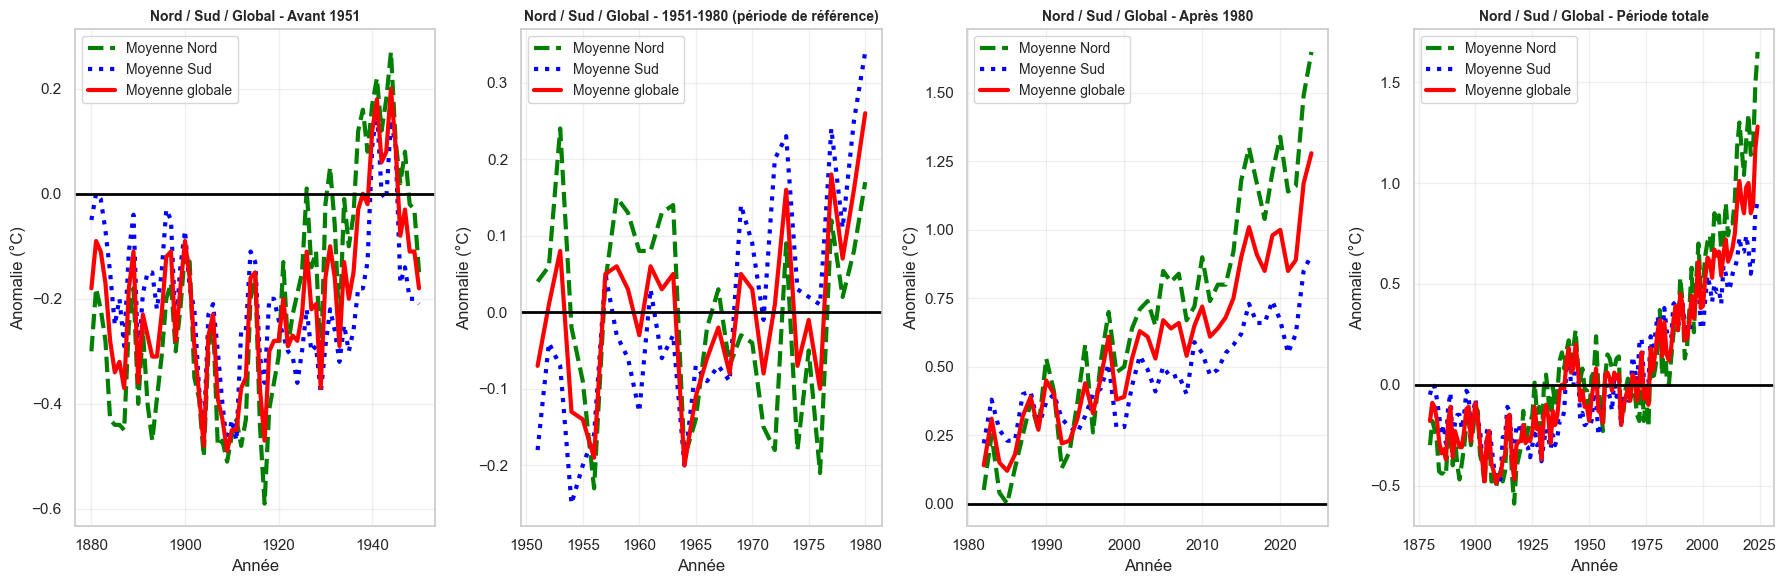

In [116]:
# Quatre graphiques côte à côte
fig, axes = plt.subplots(1, 4, figsize=(18, 6))

# Graphique de gauche avant 1951
ax1 = axes[0]

# Hémisphères Nord et Sud et global avant 1951
ax1.plot(df_avant['Year'], df_avant['NH_J-D'], label='Moyenne Nord', linewidth=3, color='green', linestyle='--')
ax1.plot(df_avant['Year'], df_avant['SH_J-D'], label='Moyenne Sud', linewidth=3, color='blue', linestyle='dotted')
ax1.plot(df_avant['Year'], df_avant['GLOB_J-D'], label='Moyenne globale', linewidth=3, color='red')

# ligne à 0 pour référence
ax1.axhline(0, color='black', linewidth=2, alpha=1)

# Titres et labels
ax1.set_title('Nord / Sud / Global - Avant 1951', fontsize=10, fontweight='bold')
ax1.set_xlabel('Année', fontsize=12)
ax1.set_ylabel('Anomalie (°C)', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Graphique central gauche période de référence (1951-1980)
ax2 = axes[1]

# Hémisphères Nord et Sud et global entre 1951 et 1980
ax2.plot(df_pendant['Year'], df_pendant['NH_J-D'], label='Moyenne Nord', linewidth=3, color='green', linestyle='--')
ax2.plot(df_pendant['Year'], df_pendant['SH_J-D'], label='Moyenne Sud', linewidth=3, color='blue', linestyle='dotted')
ax2.plot(df_pendant['Year'], df_pendant['GLOB_J-D'], label='Moyenne globale', linewidth=3, color='red')

# ligne à 0 pour référence
ax2.axhline(0, color='black', linewidth=2, alpha=1)


# Titres et labels
ax2.set_title('Nord / Sud / Global - 1951-1980 (période de référence)', fontsize=10, fontweight='bold')
ax2.set_xlabel('Année', fontsize=12)
ax2.set_ylabel('Anomalie (°C)', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# Graphique central droite après 1980
ax3 = axes[2]

# Hémisphères Nord et Sud et global entre 1951 et 1980
ax3.plot(df_apres['Year'], df_apres['NH_J-D'], label='Moyenne Nord', linewidth=3, color='green', linestyle='--')
ax3.plot(df_apres['Year'], df_apres['SH_J-D'], label='Moyenne Sud', linewidth=3, color='blue', linestyle='dotted')
ax3.plot(df_apres['Year'], df_apres['GLOB_J-D'], label='Moyenne globale', linewidth=3, color='red')

#ligne à 0 pour référence
ax3.axhline(0, color='black', linewidth=2, alpha=1)

#Titres et labels
ax3.set_title('Nord / Sud / Global - Après 1980', fontsize=10, fontweight='bold')
ax3.set_xlabel('Année', fontsize=12)
ax3.set_ylabel('Anomalie (°C)', fontsize=12)
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

#Graphique global (période complète)
ax4 = axes[3]

# Hémisphères Nord et Sud et global sur toute la période
ax4.plot(df_new['Year'], df_new['NH_J-D'], label='Moyenne Nord', linewidth=3, color='green', linestyle='--')
ax4.plot(df_new['Year'], df_new['SH_J-D'], label='Moyenne Sud', linewidth=3, color='blue', linestyle='dotted')
ax4.plot(df_new['Year'], df_new['GLOB_J-D'], label='Moyenne globale', linewidth=3, color='red')

#ligne à 0 pour référence
ax4.axhline(0, color='black', linewidth=2, alpha=1)

#Titres et labels
ax4.set_title('Nord / Sud / Global - Période totale', fontsize=10, fontweight='bold')
ax4.set_xlabel('Année', fontsize=12)
ax4.set_ylabel('Anomalie (°C)', fontsize=12)
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3)


plt.tight_layout()
plt.savefig('./images/comparaison_hemispheres_global_avant_apres_periode_reference.png', dpi=300, bbox_inches='tight')
plt.show()

Anomalie par décennie (barplot)

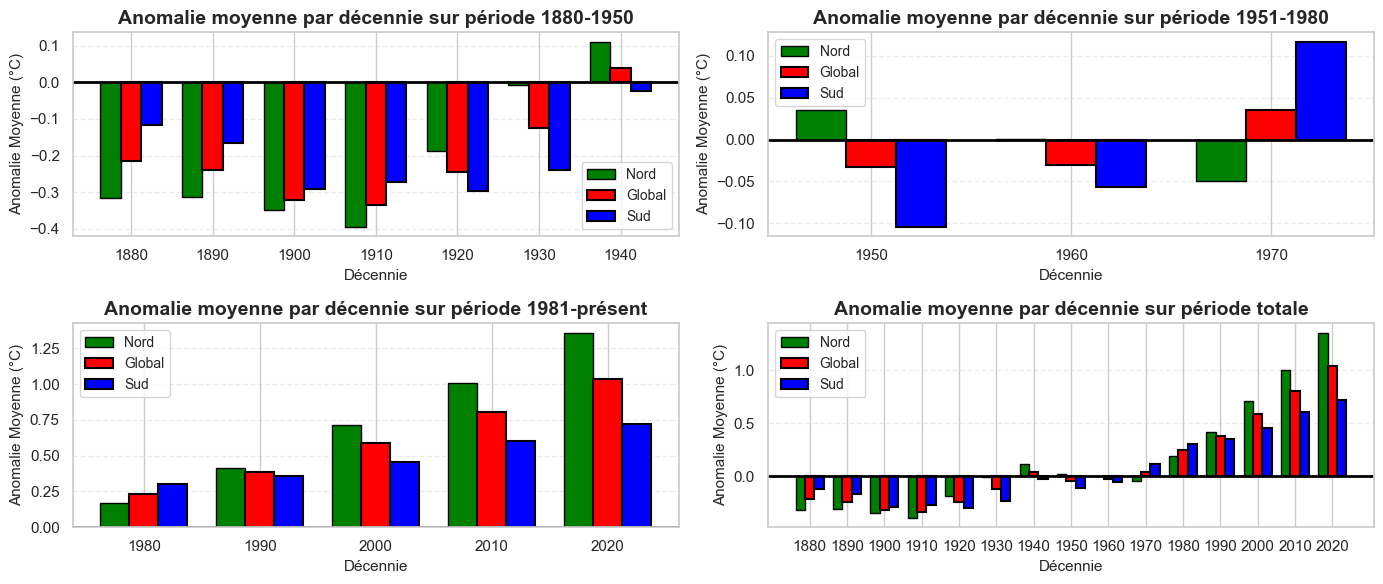

In [117]:
df_avant_decade = df_new[df_new['Year'] < 1950]   # Années avant 1951
df_pendant_decade = df_new[df_new['Year'].between(1951, 1979)]   # Années entre 1951 et 1980

# Calcul de la moyenne par décennie pour Nord, Sud et Global pour la période totale 
decade_northern_means = df_new.groupby('Decade')['NH_J-D'].mean()
decade_southern_means = df_new.groupby('Decade')['SH_J-D'].mean()
decade_global_means = df_new.groupby('Decade')['GLOB_J-D'].mean()

# Calcul de la moyenne par décennie pour Nord, Sud et Global pour la période 1880-1950 
decade_northern_avant_means = df_avant_decade.groupby('Decade')['NH_J-D'].mean()
decade_southern_avant_means = df_avant_decade.groupby('Decade')['SH_J-D'].mean()
decade_global_avant_means = df_avant_decade.groupby('Decade')['GLOB_J-D'].mean()

# Calcul de la moyenne par décennie pour Nord, Sud et Global pour la période 1951-1980
decade_northern_pendant_means = df_pendant_decade.groupby('Decade')['NH_J-D'].mean()
decade_southern_pendant_means = df_pendant_decade.groupby('Decade')['SH_J-D'].mean()
decade_global_pendant_means = df_pendant_decade.groupby('Decade')['GLOB_J-D'].mean()

# Calcul de la moyenne par décennie pour Nord, Sud et Global pour la période 1981-présent
decade_northern_apres_means = df_apres.groupby('Decade')['NH_J-D'].mean()
decade_southern_apres_means = df_apres.groupby('Decade')['SH_J-D'].mean()
decade_global_apres_means = df_apres.groupby('Decade')['GLOB_J-D'].mean()


# fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(14, 6))
fig, axes = plt.subplots(2, 2, figsize=(14, 6))
ax1 = axes[0, 0]
ax2 = axes[0, 1]
ax3 = axes[1, 0]
ax4 = axes[1, 1]

# Graphique en barres
# Définition des décennies
decades = decade_northern_means.index.values
decades_avant = decade_northern_avant_means.index.values
decades_pendant = decade_northern_pendant_means.index.values
decades_apres = decade_northern_apres_means.index.values

# Définition des anomalies moyennes pour la période totale
values_northern = decade_northern_means.values  # Nord
values_southern = decade_southern_means.values  # Sud
values_global = decade_global_means.values  # Global

# Définition des anomalies moyennes pour la période 1880-1950
values_northern_avant = decade_northern_avant_means.values  # Nord
values_southern_avant = decade_southern_avant_means.values  # Sud
values_global_avant = decade_global_avant_means.values  # Global

# Définition des anomalies moyennes pour la période 1951-1980
values_northern_pendant = decade_northern_pendant_means.values  # Nord
values_southern_pendant = decade_southern_pendant_means.values  # Sud
values_global_pendant = decade_global_pendant_means.values  # Global

# Définition des anomalies moyennes pour la période 1981-présent
values_northern_apres = decade_northern_apres_means.values  # Nord
values_southern_apres = decade_southern_apres_means.values  # Sud
values_global_apres = decade_global_apres_means.values  # Global

# Positions 0,1,2,... pour chaque période
x = np.arange(len(decades))
x_avant = np.arange(len(decades_avant))  
x_pendant = np.arange(len(decades_pendant))
x_apres = np.arange(len(decades_apres))

# Définition de la largeur des barres
width = 0.25

# Définition des couleurs (une par zone Global, Sud, Nord)
colors_northern = 'green'
colors_southern = 'blue'
colors_global = 'red'

# Dessiner les barres
bars_northern_avant = ax1.bar(x_avant - width, values_northern_avant, width, label='Nord', color=colors_northern, 
edgecolor='black')
bars_global_avant = ax1.bar(x_avant, values_global_avant, width, label='Global', color=colors_global, 
edgecolor='black', linewidth=1.5)
bars_southern_avant = ax1.bar(x_avant + width, values_southern_avant, width, label='Sud', color=colors_southern, 
edgecolor='black', linewidth=1.5)

bars_northern_pendant = ax2.bar(x_pendant - width, values_northern_pendant, width, label='Nord', color=colors_northern, edgecolor='black')
bars_global_pendant = ax2.bar(x_pendant, values_global_pendant, width, label='Global', color=colors_global, 
edgecolor='black', linewidth=1.5)
bars_southern_pendant = ax2.bar(x_pendant + width, values_southern_pendant, width, label='Sud', color=colors_southern, 
edgecolor='black', linewidth=1.5)

bars_northern_apres = ax3.bar(x_apres - width, values_northern_apres, width, label='Nord', color=colors_northern, edgecolor='black')
bars_global_apres = ax3.bar(x_apres, values_global_apres, width, label='Global', color=colors_global, 
edgecolor='black', linewidth=1.5)
bars_southern_apres = ax3.bar(x_apres + width, values_southern_apres, width, label='Sud', color=colors_southern, 
edgecolor='black', linewidth=1.5)

bars_northern = ax4.bar(x - width, values_northern, width, label='Nord', color=colors_northern, 
edgecolor='black')
bars_global = ax4.bar(x, values_global, width, label='Global', color=colors_global, 
edgecolor='black', linewidth=1.5)
bars_southern = ax4.bar(x + width, values_southern, width, label='Sud', color=colors_southern, 
edgecolor='black', linewidth=1.5)


# Valeurs au-dessus des barres
# for bar_n in bars_northern:
#  height = bar_n.get_height()
#  ax.text(bar_n.get_x() + bar_n.get_width()/2, height,
#  f'{height:.3f}°C', 
#  ha='center', va='top', rotation='vertical', fontsize=9, fontweight='bold')

# for bar_s in bars_southern:
#  height = bar_s.get_height()
#  ax.text(bar_s.get_x() + bar_s.get_width()/2, height,
#  f'{height:.3f}°C', 
#  ha='center', va='top', rotation='vertical', fontsize=9, fontweight='bold')

# for bar_g in bars_global:
#  height = bar_g.get_height()
#  ax.text(bar_g.get_x() + bar_g.get_width()/2, height,
#  f'{height:.3f}°C', 
#  ha='center', va='top', rotation='vertical', fontsize=9, fontweight='bold')

# Une ligne horizontale à 0
ax1.axhline(0, color='black', linewidth=2, alpha=1)
ax2.axhline(0, color='black', linewidth=2, alpha=1)
ax3.axhline(0, color='black', linewidth=2, alpha=1)
ax4.axhline(0, color='black', linewidth=2, alpha=1)

# Titres et labels

ax1.set_title('Anomalie moyenne par décennie sur période 1880-1950', fontsize=14, fontweight='bold')
ax1.set_xlabel('Décennie', fontsize=11)
ax1.set_ylabel('Anomalie Moyenne (°C)', fontsize=11)
ax1.set_xticks(x_avant)
ax1.set_xticklabels(decades_avant)
ax1.legend(fontsize=10)
ax1.grid(axis='y', linestyle='--', alpha=0.4)
ax1.set_axisbelow(True)

ax2.set_title('Anomalie moyenne par décennie sur période 1951-1980', fontsize=14, fontweight='bold')
ax2.set_xlabel('Décennie', fontsize=11)
ax2.set_ylabel('Anomalie Moyenne (°C)', fontsize=11)
ax2.set_xticks(x_pendant)
ax2.set_xticklabels(decades_pendant)
ax2.legend(fontsize=10)
ax2.grid(axis='y', linestyle='--', alpha=0.4)
ax2.set_axisbelow(True)

ax3.set_title('Anomalie moyenne par décennie sur période 1981-présent', fontsize=14, fontweight='bold')
ax3.set_xlabel('Décennie', fontsize=11)
ax3.set_ylabel('Anomalie Moyenne (°C)', fontsize=11)
ax3.set_xticks(x_apres)
ax3.set_xticklabels(decades_apres)
ax3.legend(fontsize=10)
ax3.grid(axis='y', linestyle='--', alpha=0.4)
ax3.set_axisbelow(True)

ax4.set_title('Anomalie moyenne par décennie sur période totale', fontsize=14, fontweight='bold')
ax4.set_xlabel('Décennie', fontsize=11)
ax4.set_ylabel('Anomalie Moyenne (°C)', fontsize=11)
ax4.set_xticks(x)
ax4.set_xticklabels(decades)
ax4.legend(fontsize=10)
ax4.grid(axis='y', linestyle='--', alpha=0.4)
ax4.set_axisbelow(True)

plt.tight_layout()
plt.savefig('./images/anomalie_par_decennie.png', dpi=300, bbox_inches='tight')
plt.show()


### Analyse plusieurs zones période totale

Accélération du réchauffement (lineplot)

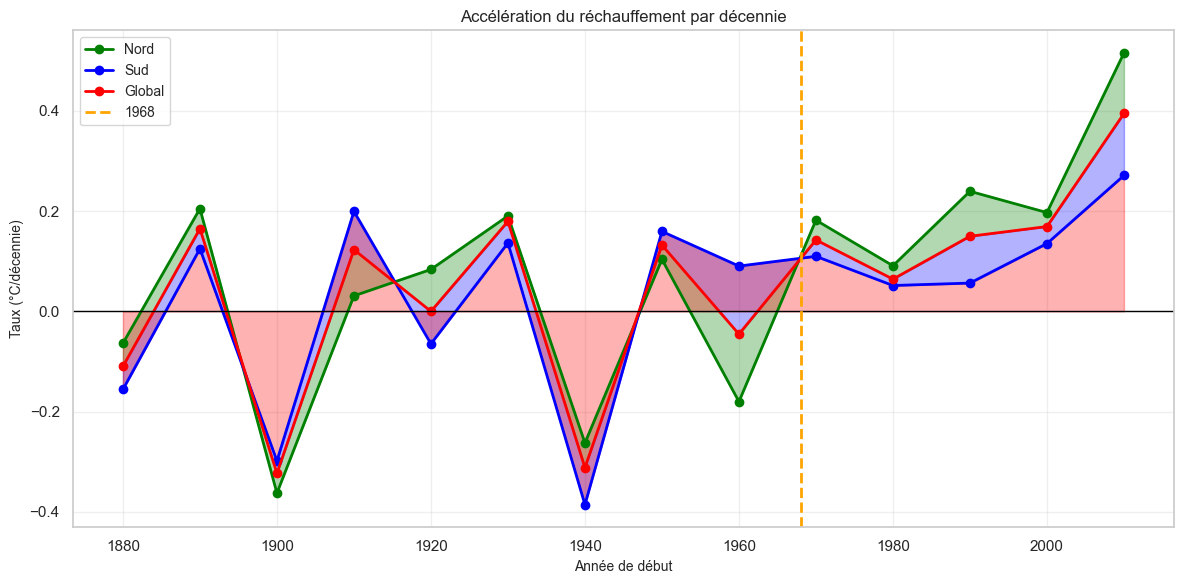

In [118]:
# 1. Calculer le taux de réchauffement pour chaque décennie
# Années de début (1880, 1890, 1900, ...)
periodes_north = []  
periodes_south = []
periodes_global = []

# Taux de réchauffement (°C par décennie)
taux_north = []
taux_south = [] 
taux_global = []

for annee_debut in range(1880, 2015, 10):
    # Prendre 10 ans de données
    annee_fin = annee_debut + 10
    donnees_north = donnees_south = donnees_global = df_new[(df_new['Year'] >= annee_debut) & (df_new['Year'] < annee_fin)]
    
    # Calculer la tendance si on a assez de données
    if len(donnees_north) >= 5:
        slope_north, _, _, _, _ = linregress(donnees_north['Year'], donnees_north['NH_J-D'])
        periodes_north.append(annee_debut)
        taux_north.append(slope_north * 10)  # Convertir en °C/décennie
    
    if len(donnees_south) >= 5:
        slope_south, _, _, _, _ = linregress(donnees_south['Year'], donnees_south['SH_J-D'])
        periodes_south.append(annee_debut)
        taux_south.append(slope_south * 10)

    if len(donnees_global) >= 5:
        slope_global, _, _, _, _ = linregress(donnees_global['Year'], donnees_global['GLOB_J-D'])
        periodes_global.append(annee_debut)
        taux_global.append(slope_global * 10)

#Créer le graphique
fig, ax = plt.subplots(figsize=(12, 6))

#Tracer la courbe
ax.plot(periodes_north, taux_north, marker='o', label='Nord', linewidth=2, markersize=6, color='green')
ax.plot(periodes_south, taux_south, marker='o', label='Sud', linewidth=2, markersize=6, color="blue")
ax.plot(periodes_global, taux_global, marker='o', label='Global', linewidth=2, markersize=6, color="red")

#Ajouter des lignes de référence
ax.axhline(0, color='black', linewidth=1)           # Ligne à 0
ax.axvline(1968, color='orange', linewidth=2, 
           linestyle='--', label='1968')            # Année charnière

#Remplir sous la courbe
ax.fill_between(periodes_north, taux_north, taux_global, alpha=0.3, color='green')
ax.fill_between(periodes_global, taux_global, taux_south, alpha=0.3, color='blue')
ax.fill_between(periodes_south, taux_south, 0, alpha=0.3, color='red')

#Titres et labels
ax.set_title('Accélération du réchauffement par décennie', fontsize=12)
ax.set_xlabel('Année de début', fontsize=10)
ax.set_ylabel('Taux (°C/décennie)', fontsize=10)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

#Afficher
plt.tight_layout()
plt.savefig('./images/comparaison_hemispheres_global_acceleration_rechauffement.png', dpi=300, bbox_inches='tight')
plt.show()


Distribution données pour les colonnes sélectionnées (boxplot)

C:\Users\Vincent\AppData\Local\Temp\ipykernel_23180\1214468240.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


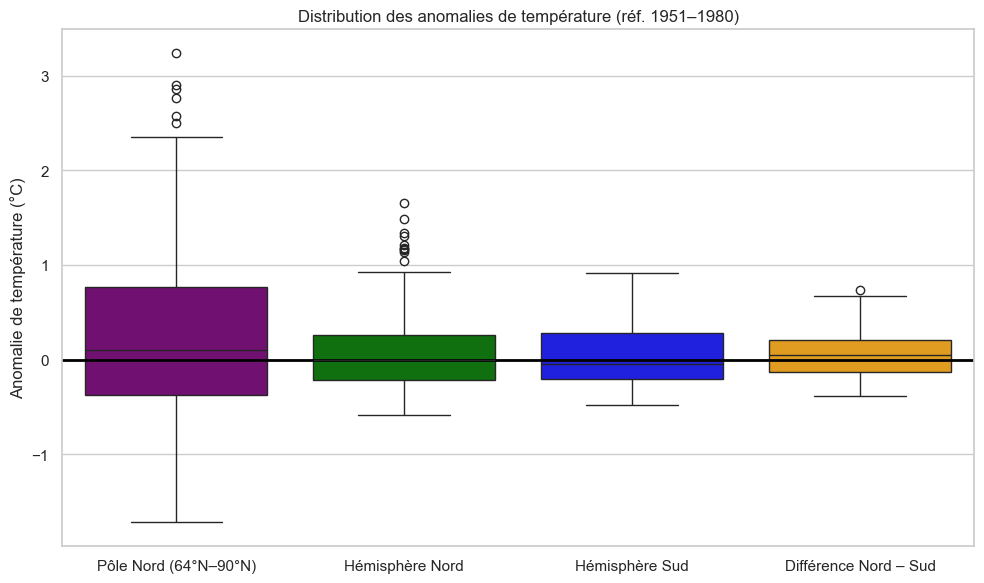

In [119]:
# Sélection des colonnes d'anomalies
cols = [
    'Zon_64N-90N',
    'NH_J-D',
    'SH_J-D',
    'Diff_North_South'
]

labels = {
    'Zon_64N-90N': 'Pôle Nord (64°N–90°N)',
    'NH_J-D': 'Hémisphère Nord',
    'SH_J-D': 'Hémisphère Sud',
    'Diff_North_South': 'Différence Nord – Sud'
}

# Création d'un DataFrame long (format tidy)
df_long = df_new_light[list(labels.keys())].melt(
    var_name='Région',
    value_name='Anomalie (°C)'
)

# Remplacement des noms
df_long['Région'] = df_long['Région'].map(labels)

# Style
sns.set(style="whitegrid")

palette_custom = {
    'Pôle Nord (64°N–90°N)': 'purple',
    'Hémisphère Nord': 'green',
    'Hémisphère Sud': 'blue', 
    'Différence Nord – Sud': 'orange'
}


plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_long,
    x='Région',
    y='Anomalie (°C)',
    legend=False,
    palette=palette_custom,
    showfliers=True
)

plt.axhline(0, color='black', linewidth=2)
plt.title("Distribution des anomalies de température (réf. 1951–1980)")
plt.ylabel("Anomalie de température (°C)")
plt.xlabel("")
plt.tight_layout()
plt.savefig('./images/distribution_anomalies_arctique_nord_sud_differentiel_periode_totale.png', dpi=300, bbox_inches='tight')
plt.show()


### Analyse d'une seule zone ou variable

Heatmap Global par année et décennie

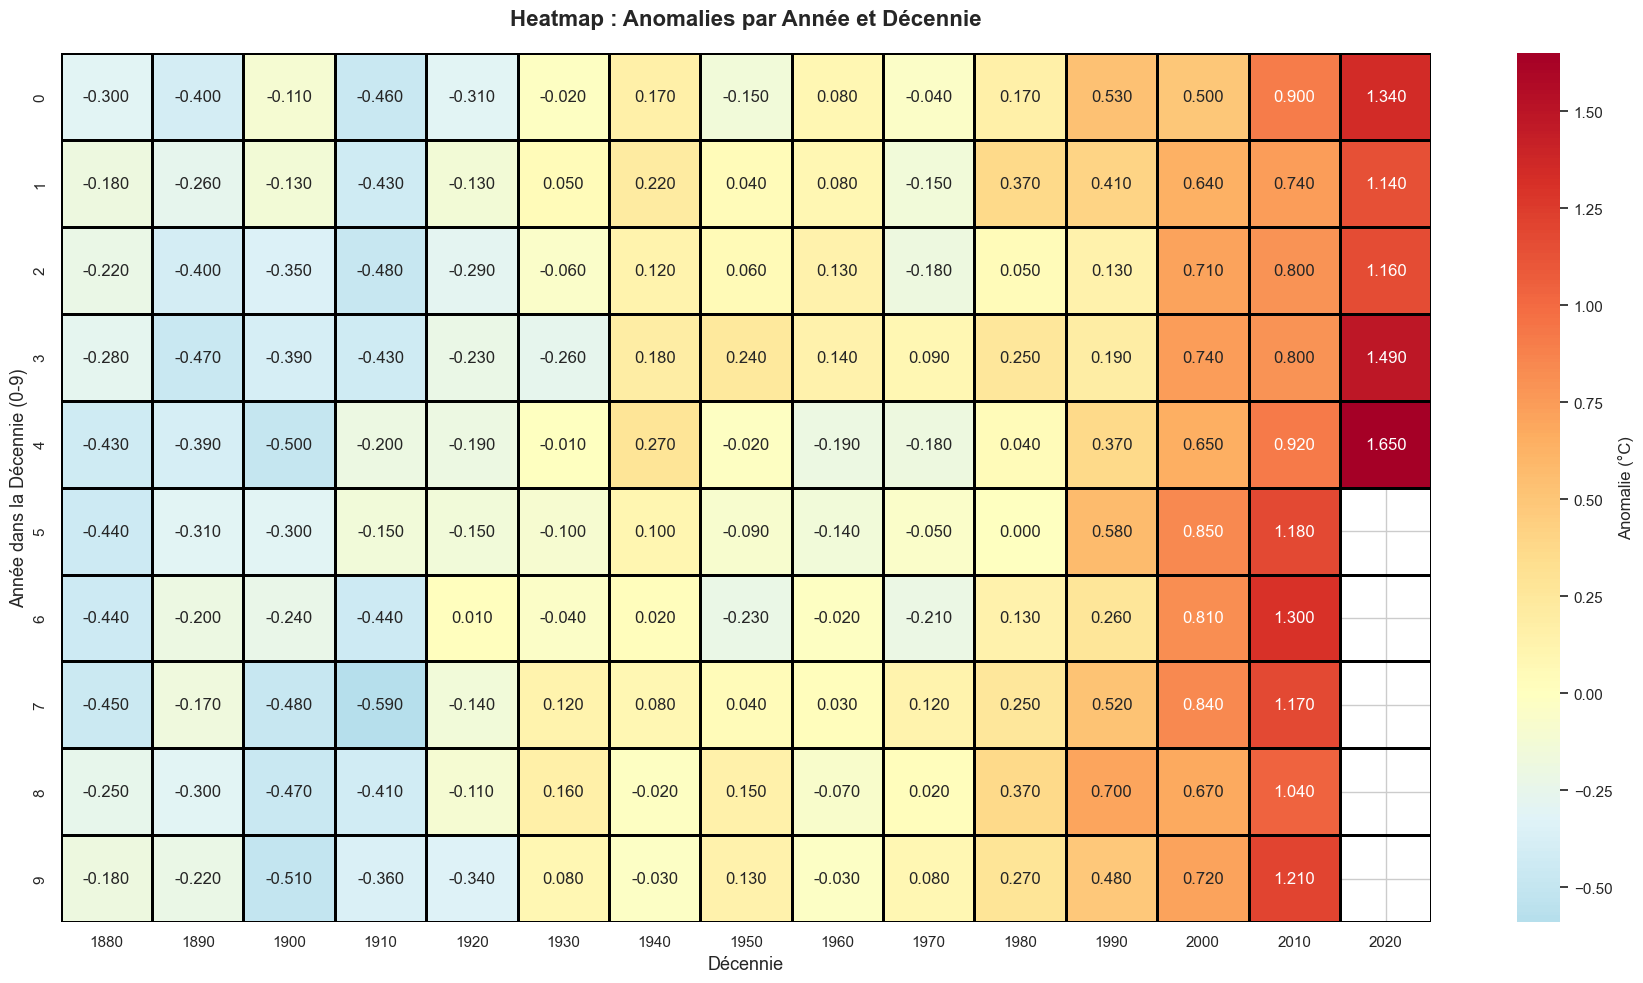

In [120]:
fig2, ax = plt.subplots(figsize=(18, 10))

#matrice année x décennie
df_new['Decade'] = (df_new['Year'] // 10) * 10
df_new['YearInDecade'] = df_new['Year'] % 10

pivot_data = df_new.pivot_table(values='NH_J-D', index='YearInDecade', columns='Decade', aggfunc='mean')

sns.heatmap(pivot_data, annot=True, fmt='.3f', cmap='RdYlBu_r', 
center=0, linewidths=1, linecolor='black', 
cbar_kws={'label': 'Anomalie (°C)'}, ax=ax)

ax.set_title('Heatmap : Anomalies par Année et Décennie', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Décennie', fontsize=13)
ax.set_ylabel('Année dans la Décennie (0-9)', fontsize=13)

plt.tight_layout()
plt.savefig('./images/heatmap_temperature.png', dpi=300, bbox_inches='tight')
plt.show()



Anomalie par année (lineplot)

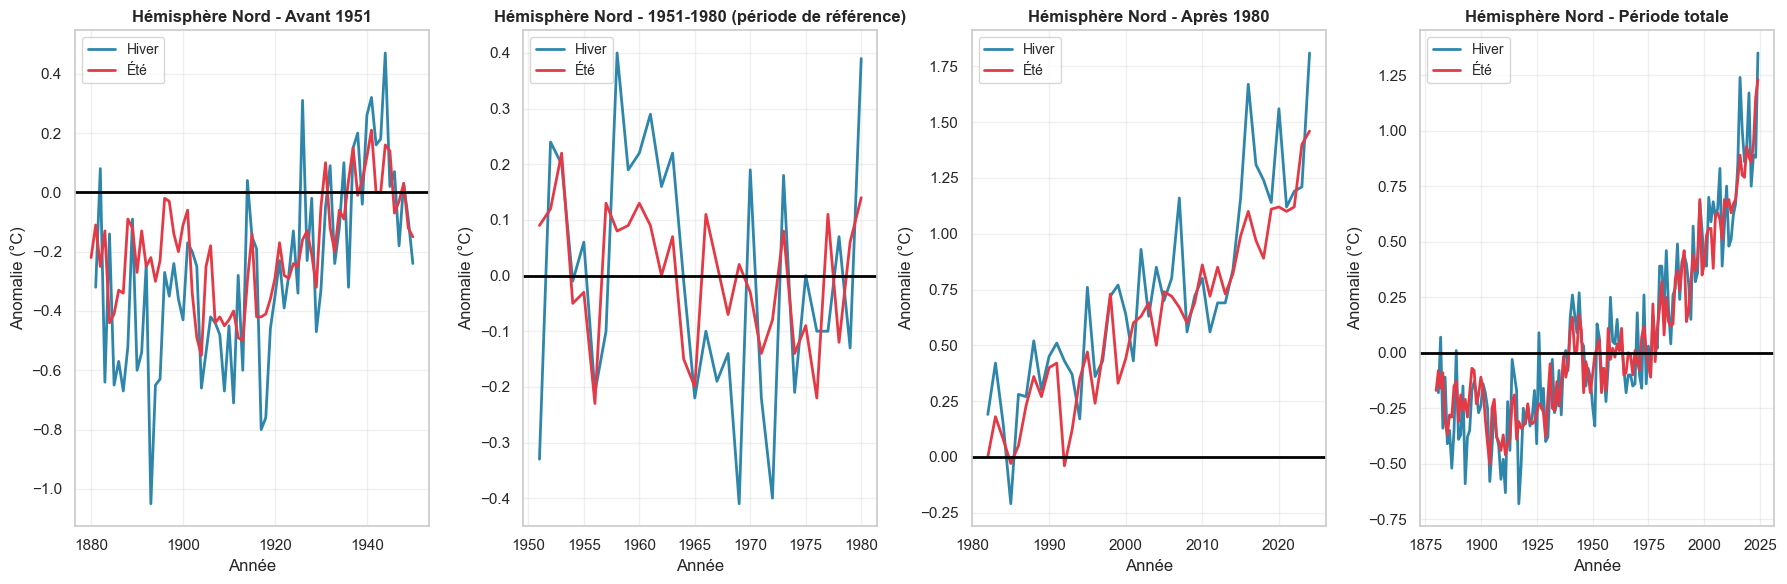

In [121]:
# Quatre graphiques côte à côte
fig, axes = plt.subplots(1, 4, figsize=(18, 6))

# Graphique de gauche avant 1951
ax1 = axes[0]

# 4 saisons + moyenne
ax1.plot(df_avant['Year'], df_avant['NH_DJF'], label='Hiver', linewidth=2, color='#2E86AB')
# ax1.plot(df_avant['Year'], df_avant['NH_MAM'], label='Printemps', linewidth=2, color='#06A77D')
ax1.plot(df_avant['Year'], df_avant['NH_JJA'], label='Été', linewidth=2, color='#E63946')
# ax1.plot(df_avant['Year'], df_avant['NH_SON'], label='Automne', linewidth=2, color='#F77F00')
# ax1.plot(df_avant['Year'], df_avant['NH_J-D'], label='Moyenne', linewidth=3, color='green', linestyle='--')

# ligne à 0 pour référence
ax1.axhline(0, color='black', linewidth=2, alpha=1)

# Titres et labels
ax1.set_title('Hémisphère Nord - Avant 1951', fontsize=12, fontweight='bold')
ax1.set_xlabel('Année', fontsize=12)
ax1.set_ylabel('Anomalie (°C)', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Graphique central période de référence (1951-1980)
ax2 = axes[1]

# 4 saisons + moyenne
ax2.plot(df_pendant['Year'], df_pendant['NH_DJF'], label='Hiver', linewidth=2, color='#2E86AB')
# ax2.plot(df_pendant['Year'], df_pendant['NH_MAM'], label='Printemps', linewidth=2, color='#06A77D')
ax2.plot(df_pendant['Year'], df_pendant['NH_JJA'], label='Été', linewidth=2, color='#E63946')
# ax2.plot(df_pendant['Year'], df_pendant['NH_SON'], label='Automne', linewidth=2, color='#F77F00')
# ax2.plot(df_pendant['Year'], df_pendant['NH_J-D'], label='Moyenne', linewidth=3, color='orange', linestyle='--')

#ligne à 0 pour référence
ax2.axhline(0, color='black', linewidth=2, alpha=1)


#Titres et labels
ax2.set_title('Hémisphère Nord - 1951-1980 (période de référence)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Année', fontsize=12)
ax2.set_ylabel('Anomalie (°C)', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

#Graphique de droite après 1980
ax3 = axes[2]

# 4 saisons + moyenne
ax3.plot(df_apres['Year'], df_apres['NH_DJF'], label='Hiver', linewidth=2, color='#2E86AB')
# ax3.plot(df_apres['Year'], df_apres['NH_MAM'], label='Printemps', linewidth=2, color='#06A77D')
ax3.plot(df_apres['Year'], df_apres['NH_JJA'], label='Été', linewidth=2, color='#E63946')
# ax3.plot(df_apres['Year'], df_apres['NH_SON'], label='Automne', linewidth=2, color='#F77F00')
# ax3.plot(df_apres['Year'], df_apres['NH_J-D'], label='Moyenne', linewidth=3, color='red', linestyle='--')

#ligne à 0 pour référence
ax3.axhline(0, color='black', linewidth=2, alpha=1)

#Titres et labels
ax3.set_title('Hémisphère Nord - Après 1980', fontsize=12, fontweight='bold')
ax3.set_xlabel('Année', fontsize=12)
ax3.set_ylabel('Anomalie (°C)', fontsize=12)
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

#Graphique global (période complète)
ax4 = axes[3]

# 4 saisons + moyenne
ax4.plot(df_new['Year'], df_new['GLOB_DJF'], label='Hiver', linewidth=2, color='#2E86AB')
# ax4.plot(df_new['Year'], df_new['GLOB_MAM'], label='Printemps', linewidth=2, color='#06A77D')
ax4.plot(df_new['Year'], df_new['GLOB_JJA'], label='Été', linewidth=2, color='#E63946')
# ax4.plot(df_new['Year'], df_new['GLOB_SON'], label='Automne', linewidth=2, color='#F77F00')
# ax4.plot(df_new['Year'], df_new['GLOB_J-D'], label='Moyenne', linewidth=3, color='blue', linestyle='--')

#ligne à 0 pour référence
ax4.axhline(0, color='black', linewidth=2, alpha=1)

#Titres et labels
ax4.set_title('Hémisphère Nord - Période totale', fontsize=12, fontweight='bold')
ax4.set_xlabel('Année', fontsize=12)
ax4.set_ylabel('Anomalie (°C)', fontsize=12)
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3)


plt.tight_layout()
plt.savefig('./images/comparaison_nord_avant_apres_periode_reference.png', dpi=300, bbox_inches='tight')
plt.show()

Différentiel températures moyenne Nord / Sud par année (lineplot)

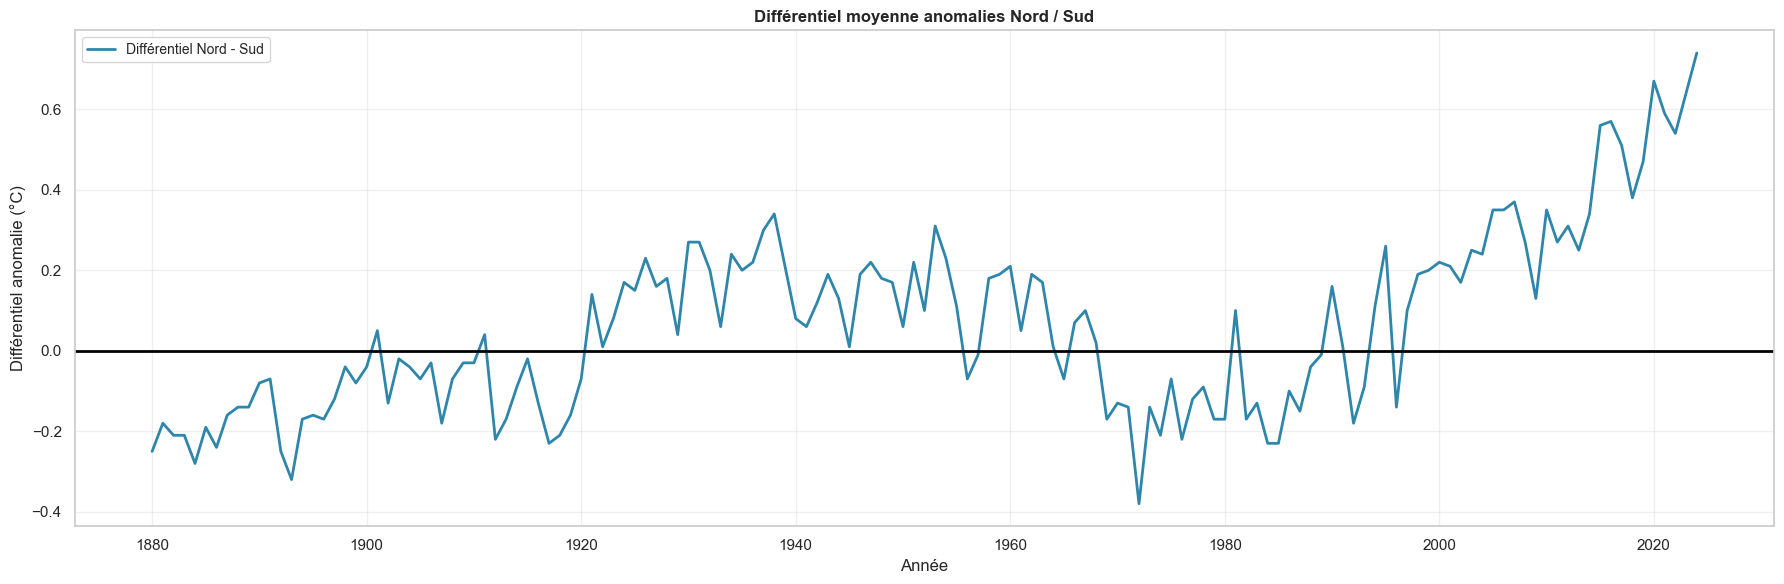

In [122]:
fig, ax = plt.subplots(figsize=(18, 6))

# 4 saisons + moyenne
ax.plot(df_new_light
['Year'], df_new_light
['Diff_North_South'], label='Différentiel Nord - Sud', linewidth=2, color='#2E86AB')

# ligne à 0 pour référence
ax.axhline(0, color='black', linewidth=2, alpha=1)

# Titres et labels
ax.set_title('Différentiel moyenne anomalies Nord / Sud', fontsize=12, fontweight='bold')
ax.set_xlabel('Année', fontsize=12)
ax.set_ylabel('Différentiel anomalie (°C)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./images/differentiel_moyennes_nord_sud_periode_totale.png', dpi=300, bbox_inches='tight')
plt.show()

Distribution données par décennie pour une colonne sélectionnée (boxplot) 

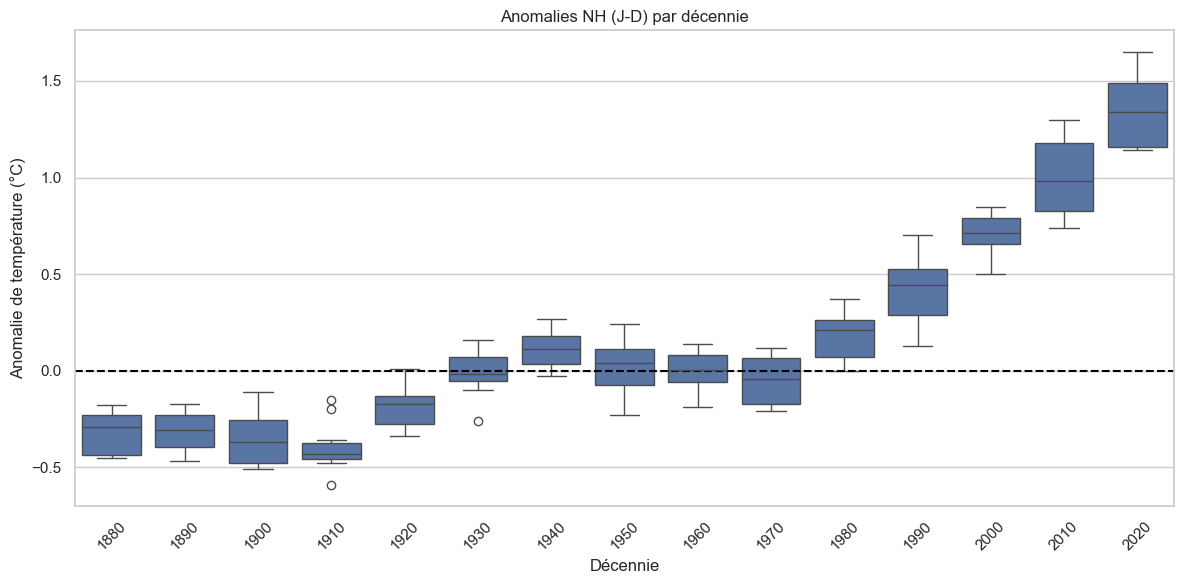

In [123]:
# Création des décennies
df_new_light['Decade'] = (df_new_light['Year'] // 10) * 10

# Exemple pour NH_J-D (à répéter pour les autres si besoin)
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_new_light,
    x='Decade',
    y='NH_J-D',
    showfliers=True
)

plt.axhline(0, color='black', linestyle='--')
plt.title("Anomalies NH (J-D) par décennie")
plt.ylabel("Anomalie de température (°C)")
plt.xlabel("Décennie")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('./images/distribution_anomalies_nord_decennie_periode_totale.png', dpi=300, bbox_inches='tight')
plt.show()